# Final Project Analysis: Ride On Reimagined And Transit Equity

**Student:** Emmanuel Opoku-Boateng  
**Course:** URSP688Y Urban Data Science & Smart Cities

## Research Question And Hypothesis

**Main question:** Did Ride On Reimagined produce larger scheduled service gains in higher-transit-need neighborhoods than in lower-transit-need neighborhoods?

**Hypothesis:** Higher-transit-need tracts received larger scheduled service gains after Ride On Reimagined Phase 1/Year 1 implementation than lower-transit-need tracts.

The Analysis:
1. **Identifies higher-transit-need areas** using ACS tract indicators.
2. **Measures scheduled Ride On service** using GTFS feeds before and after implementation.
3. **Joins ACS need data to GTFS service data** at the Census tract level.
4. **Compares pre/post service change** across transit need quartiles.

The analysis is focused on scheduled service supply. It does not claim to measure actual rider experience, reliability, crowding, safety, fare burden, or full destination accessibility.

## 1. Loading the needed Python Tools

1. Import path tools so the notebook can locate project files.
2. Import pandas for tables and summaries.
3. Import display tools for showing saved figures.
4. Import the final analysis pipeline so the notebook can recreate outputs.
5. Set pandas display options to make output easier to inspect.


In [1]:
# Import Path so file locations are built clearly and reproducibly.
from pathlib import Path

# Import pandas so we can read and summarize CSV outputs.
import pandas as pd

# Import display helpers so saved maps and charts appear in the notebook.
from IPython.display import Image, display

# Import the reproducible final analysis pipeline from the local script.
from final_project_analysis import main as run_final_analysis

# Show more columns when previewing joined data tables.
pd.set_option("display.max_columns", 120)


## 2. Run The Analysis Pipeline

1. Run the final project script.


In [2]:
# Run the complete final analysis pipeline.
run_final_analysis()


In [3]:
# Treat the current notebook folder as the project folder.
project_dir = Path.cwd()

# Point to the processed final-analysis tables.
final_output_dir = project_dir / "data" / "processed" / "final_analysis"

# Point to the saved final-analysis maps and charts.
final_figure_dir = project_dir / "figures" / "final_analysis"

# Confirm that the expected output folders exist.
final_output_dir.exists(), final_figure_dir.exists()


(True, True)

## 3. Confirming The Pre/Post GTFS Timing

1. Read the GTFS feed inventory.
2. Keep the feed label, role, active dates, and representative analysis dates.
3. Use the feed dates to confirm which feed is pre-implementation and which feed is post-implementation.


In [4]:
# Read the GTFS feed inventory created during data preparation.
gtfs_inventory = pd.read_csv(project_dir / "data" / "processed" / "gtfs" / "gtfs_feed_inventory.csv")

# Select the timing fields that explain the pre/post design.
feed_timing = gtfs_inventory[
    [
        "feed_label",
        "role",
        "feed_start_date",
        "feed_end_date",
        "representative_tuesday",
        "representative_saturday",
    ]
]

# Display the feed timing table.
feed_timing


,feed_label,role,feed_start_date,feed_end_date,representative_tuesday,representative_saturday
0,2024_january,early_pre_implementation_context,20240114,20240504,2024-01-16,2024-01-20
1,2024_may,pre_implementation_context,20240505,20240907,2024-05-07,2024-05-11
2,2024_september,pre_implementation_context,20240908,20250111,2024-09-10,2024-09-14
3,2025_january,primary_pre_phase1_baseline,20250112,20250628,2025-01-14,2025-01-18
4,2025_june,primary_post_phase1_feed,20250629,20250906,2025-07-01,2025-07-05
5,2025_september,post_phase1_followup,20250907,20260110,2025-09-09,2025-09-13
6,2026_may_current,published_current_feed_as_of_2026_04_30,20260503,20260905,2026-05-05,2026-05-09


## 4. Loading The Joined ACS + GTFS Tract Panel

1. Read the tract-by-feed panel.
2. Count tracts, feeds, and rows.
3. Use the counts to verify that the panel covers the full prepared dataset.


In [5]:
# Read the main tract-level panel that joins service measures and ACS indicators.
panel = pd.read_csv(final_output_dir / "tract_service_panel_025mi.csv")

# Summarize the size of the panel.
panel_summary = pd.DataFrame(
    {
        "unique_tracts": [panel["GEOID"].nunique()],
        "unique_gtfs_feeds": [panel["feed_label"].nunique()],
        "panel_rows": [len(panel)],
    }
)

# Display the panel size summary.
panel_summary


,unique_tracts,unique_gtfs_feeds,panel_rows
0,232,7,1624


## 5. Check That ACS Data Were Joined To GTFS Data

1. Filter to one feed and select columns from both sides of the join.
3. Show ACS need variables next to GTFS scheduled-service variables.


In [6]:
# Keep one feed for a compact join preview.
joined_preview = panel.loc[panel["feed_label"] == "2025_january"].copy()

# Select ACS fields and GTFS service fields from the same tract rows.
joined_preview = joined_preview[
    [
        "GEOID",
        "tract_name",
        "pct_households_no_vehicle",
        "pct_people_below_poverty",
        "pct_age_65_plus",
        "pct_disabled",
        "transit_need_index",
        "transit_need_quartile",
        "accessible_stop_count",
        "weekday_total_trips_accessible",
        "weekday_trips_per_1000_residents",
    ]
]

# Display the joined ACS and GTFS evidence.
joined_preview.head(10)


,GEOID,tract_name,pct_households_no_vehicle,pct_people_below_poverty,pct_age_65_plus,pct_disabled,transit_need_index,transit_need_quartile,accessible_stop_count,weekday_total_trips_accessible,weekday_trips_per_1000_residents
696,24031705601,Census Tract 7056.01; Montgomery County; Maryland,0.6,4.3,13.4,4.0,-0.780482,low,52.0,1501.0,446.859184
697,24031705501,Census Tract 7055.01; Montgomery County; Maryland,30.1,6.0,15.0,11.5,0.675107,high,32.0,1221.0,558.810069
698,24031705701,Census Tract 7057.01; Montgomery County; Maryland,6.2,4.9,17.4,5.3,-0.407900,moderate_low,59.0,1958.0,404.796361
699,24031705702,Census Tract 7057.02; Montgomery County; Maryland,0.6,2.3,25.6,9.4,-0.262442,moderate_low,67.0,2150.0,442.842430
700,24031705901,Census Tract 7059.01; Montgomery County; Maryland,9.5,3.4,25.9,7.4,-0.040027,moderate_high,77.0,1796.0,421.398405
701,24031706009,Census Tract 7060.09; Montgomery County; Maryland,0.5,4.1,23.1,6.3,-0.424118,low,21.0,248.0,48.174048
702,24031700610,Census Tract 7006.10; Montgomery County; Maryland,0.4,1.9,26.0,7.6,-0.375655,moderate_low,27.0,1026.0,509.181141
703,24031706008,Census Tract 7060.08; Montgomery County; Maryland,3.2,3.1,26.1,6.8,-0.279162,moderate_low,16.0,159.0,29.702970
704,24031705800,Census Tract 7058; Montgomery County; Maryland,2.4,2.0,21.3,5.3,-0.552697,low,90.0,2127.0,347.208619
705,24031701303,Census Tract 7013.03; Montgomery County; Maryland,0.5,3.0,28.5,9.4,-0.164399,moderate_high,36.0,1011.0,271.118262


## 6. Identifying Higher-Transit-Need Areas With ACS

1. Select the ACS variables used in the Transit Need Index.
2. Sort tracts from highest to lowest Transit Need Index.
3. Display the highest-need tracts as areas that may deserve transit equity attention.


In [7]:
# Keep one row per tract so each tract appears once.
tract_need = panel.loc[panel["feed_label"] == "2025_january"].copy()

# Select the ACS variables that define transit need.
tract_need = tract_need[
    [
        "GEOID",
        "tract_name",
        "pct_households_no_vehicle",
        "pct_people_below_poverty",
        "pct_age_65_plus",
        "pct_disabled",
        "transit_need_index",
        "transit_need_percentile",
        "transit_need_quartile",
    ]
]

# Sort by the Transit Need Index to identify the highest-need tracts.
highest_need_tracts = tract_need.sort_values("transit_need_index", ascending=False).head(10)

# Display the top ten highest-need tracts.
highest_need_tracts


,GEOID,tract_name,pct_households_no_vehicle,pct_people_below_poverty,pct_age_65_plus,pct_disabled,transit_need_index,transit_need_percentile,transit_need_quartile
849,24031703218,Census Tract 7032.18; Montgomery County; Maryland,13.9,8.7,90.0,38.5,3.635821,1.000000,high
875,24031703219,Census Tract 7032.19; Montgomery County; Maryland,12.4,13.7,91.6,31.6,3.454864,0.995690,high
873,24031700723,Census Tract 7007.23; Montgomery County; Maryland,34.3,14.5,40.5,25.0,2.545624,0.991379,high
848,24031706012,Census Tract 7060.12; Montgomery County; Maryland,18.3,19.7,27.8,26.0,2.002037,0.987069,high
772,24031700901,Census Tract 7009.01; Montgomery County; Maryland,29.1,16.8,29.7,18.7,1.861281,0.982759,high
813,24031701425,Census Tract 7014.25; Montgomery County; Maryland,20.3,5.4,40.1,24.0,1.657578,0.978448,high
863,24031705602,Census Tract 7056.02; Montgomery County; Maryland,19.9,9.5,45.9,15.6,1.494023,0.974138,high
876,24031703216,Census Tract 7032.16; Montgomery County; Maryland,12.2,5.9,58.8,16.5,1.469951,0.969828,high
922,24031701900,Census Tract 7019; Montgomery County; Maryland,23.3,38.9,7.4,7.2,1.416181,0.965517,high
782,24031700904,Census Tract 7009.04; Montgomery County; Maryland,31.2,25.1,12.9,7.6,1.243329,0.961207,high


## 7. Mapping The ACS Transit Need Index

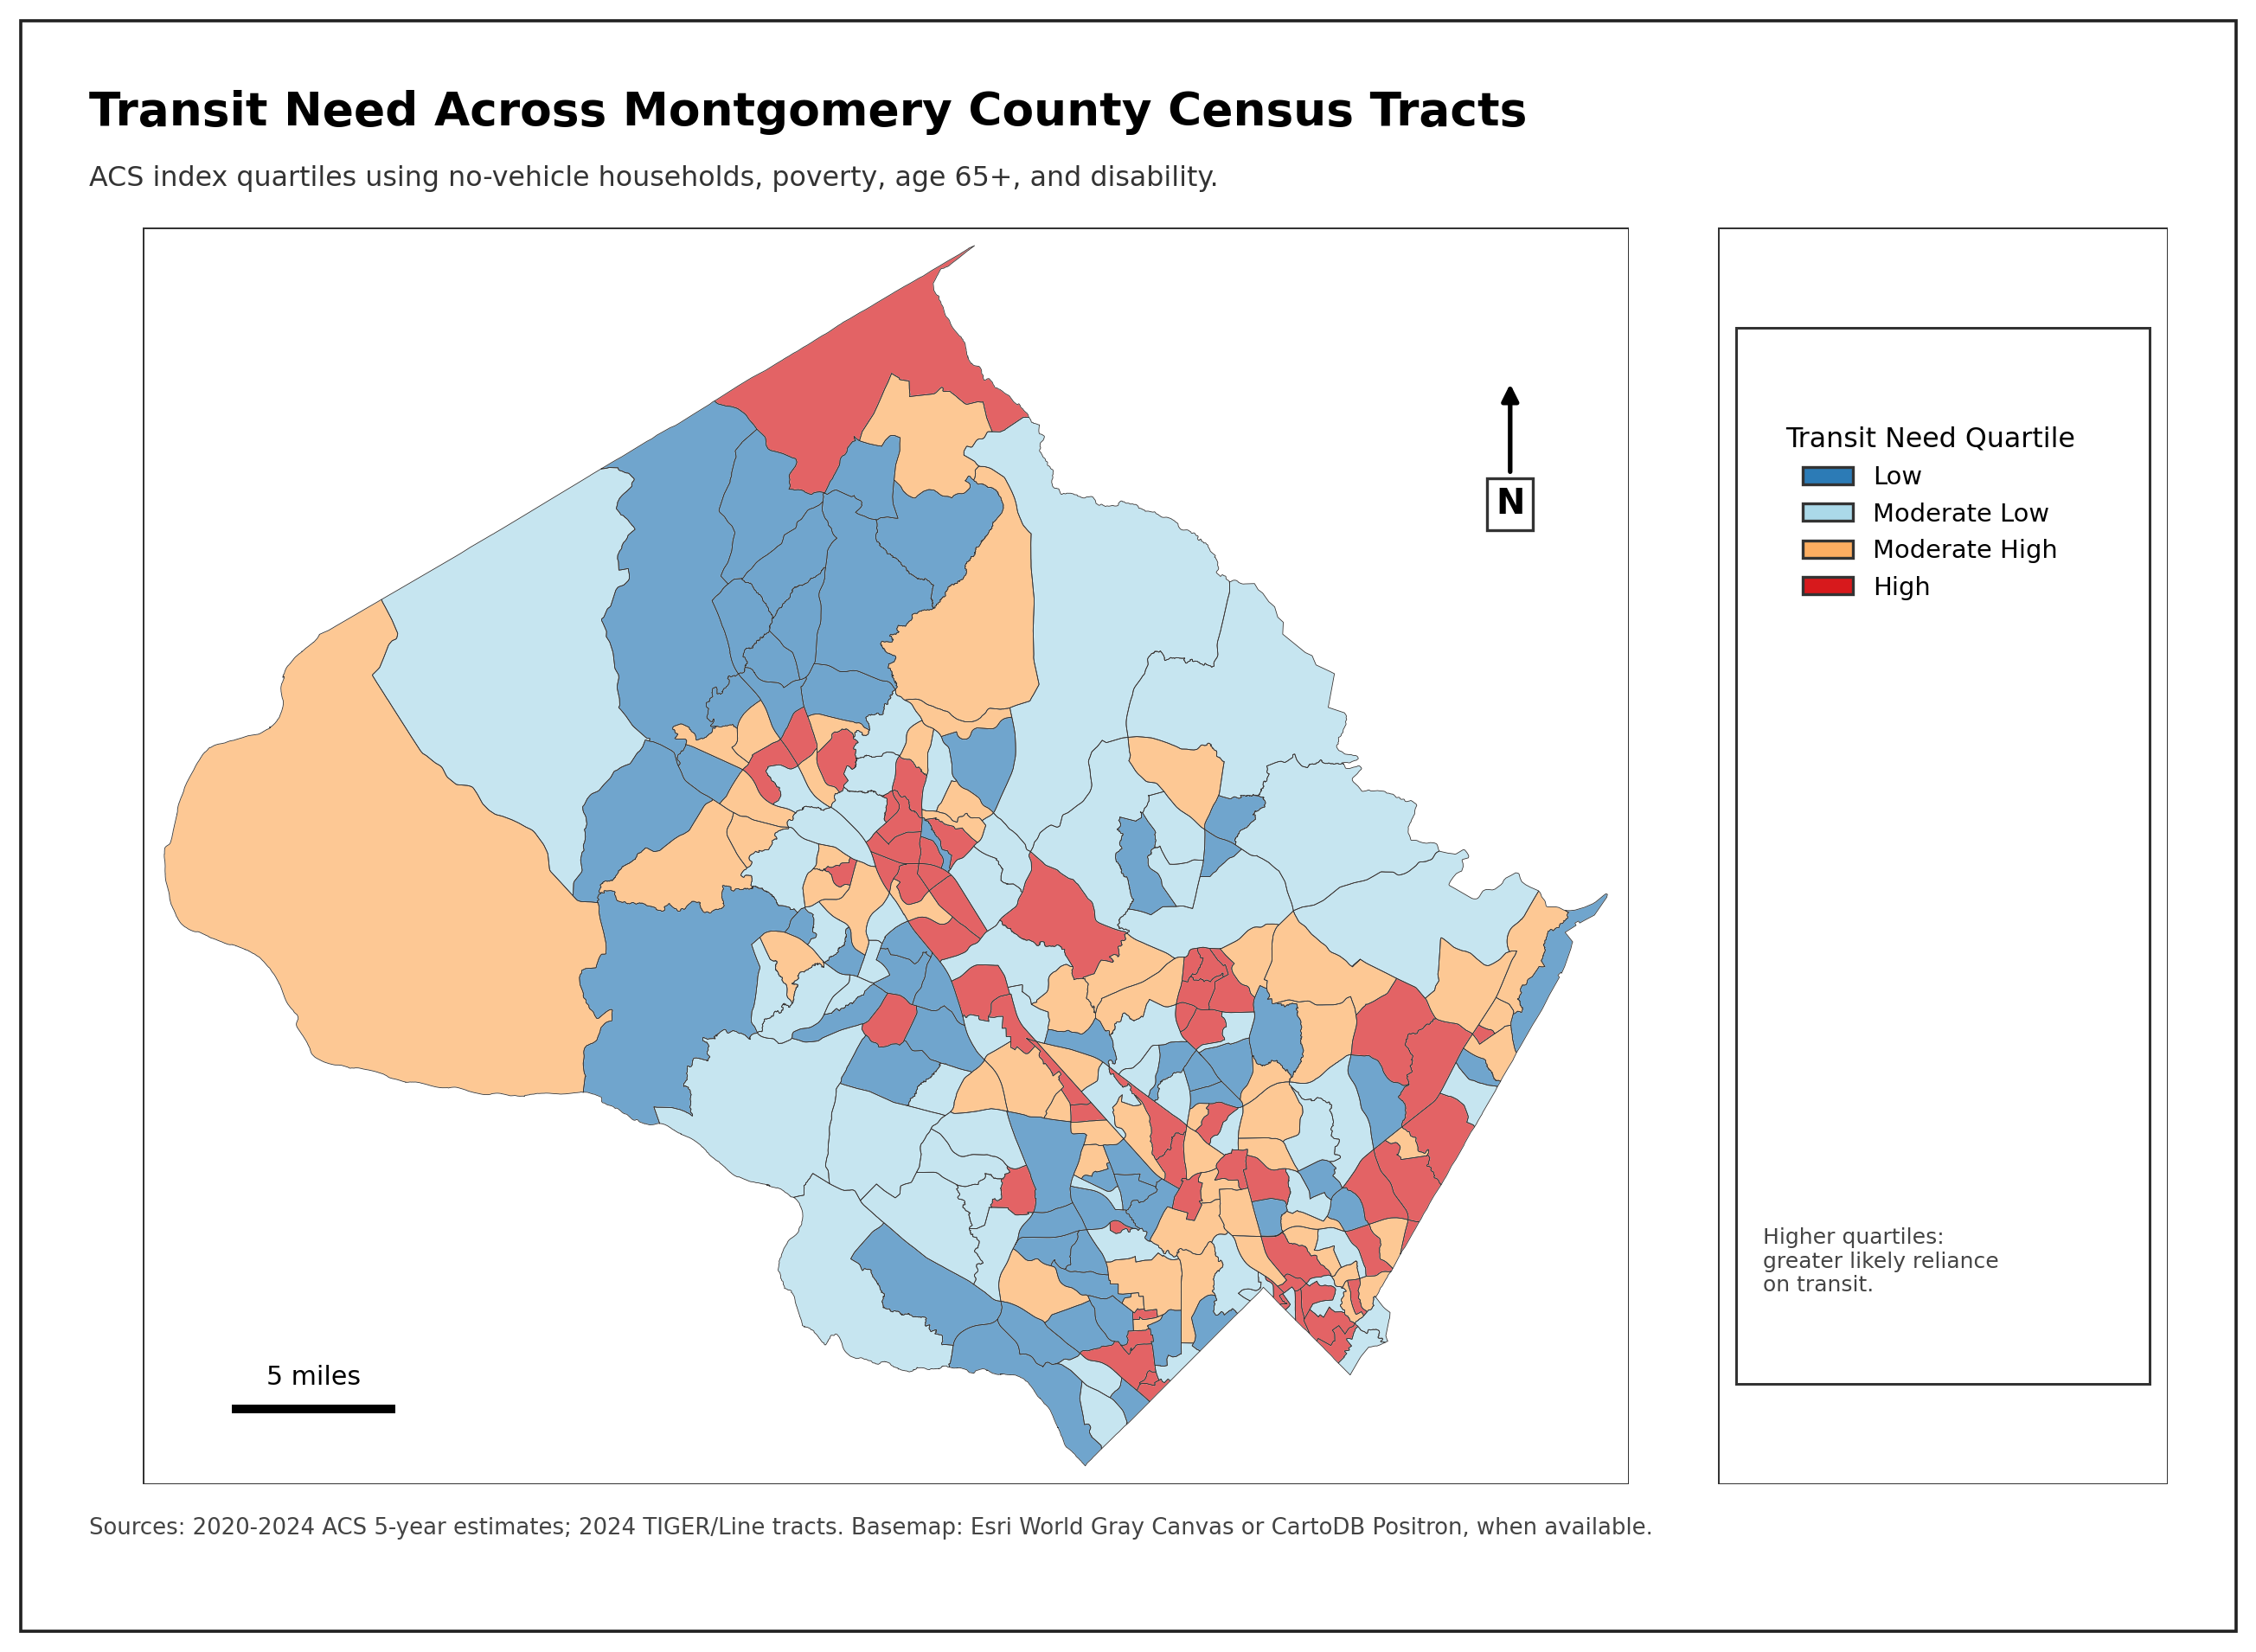

In [8]:
# Display the ACS Transit Need Index quartile map.
display(Image(filename=str(final_figure_dir / "map_01_transit_need_quartiles.png")))


This map shows the spatial distribution of the ACS Transit Need Index across Montgomery County tracts. The highest-need tracts are not evenly distributed across the county; they appear in selected clusters and corridors, especially in more urbanized parts of the county.

## 8. Charting Scheduled Service Trends Across All GTFS Feeds


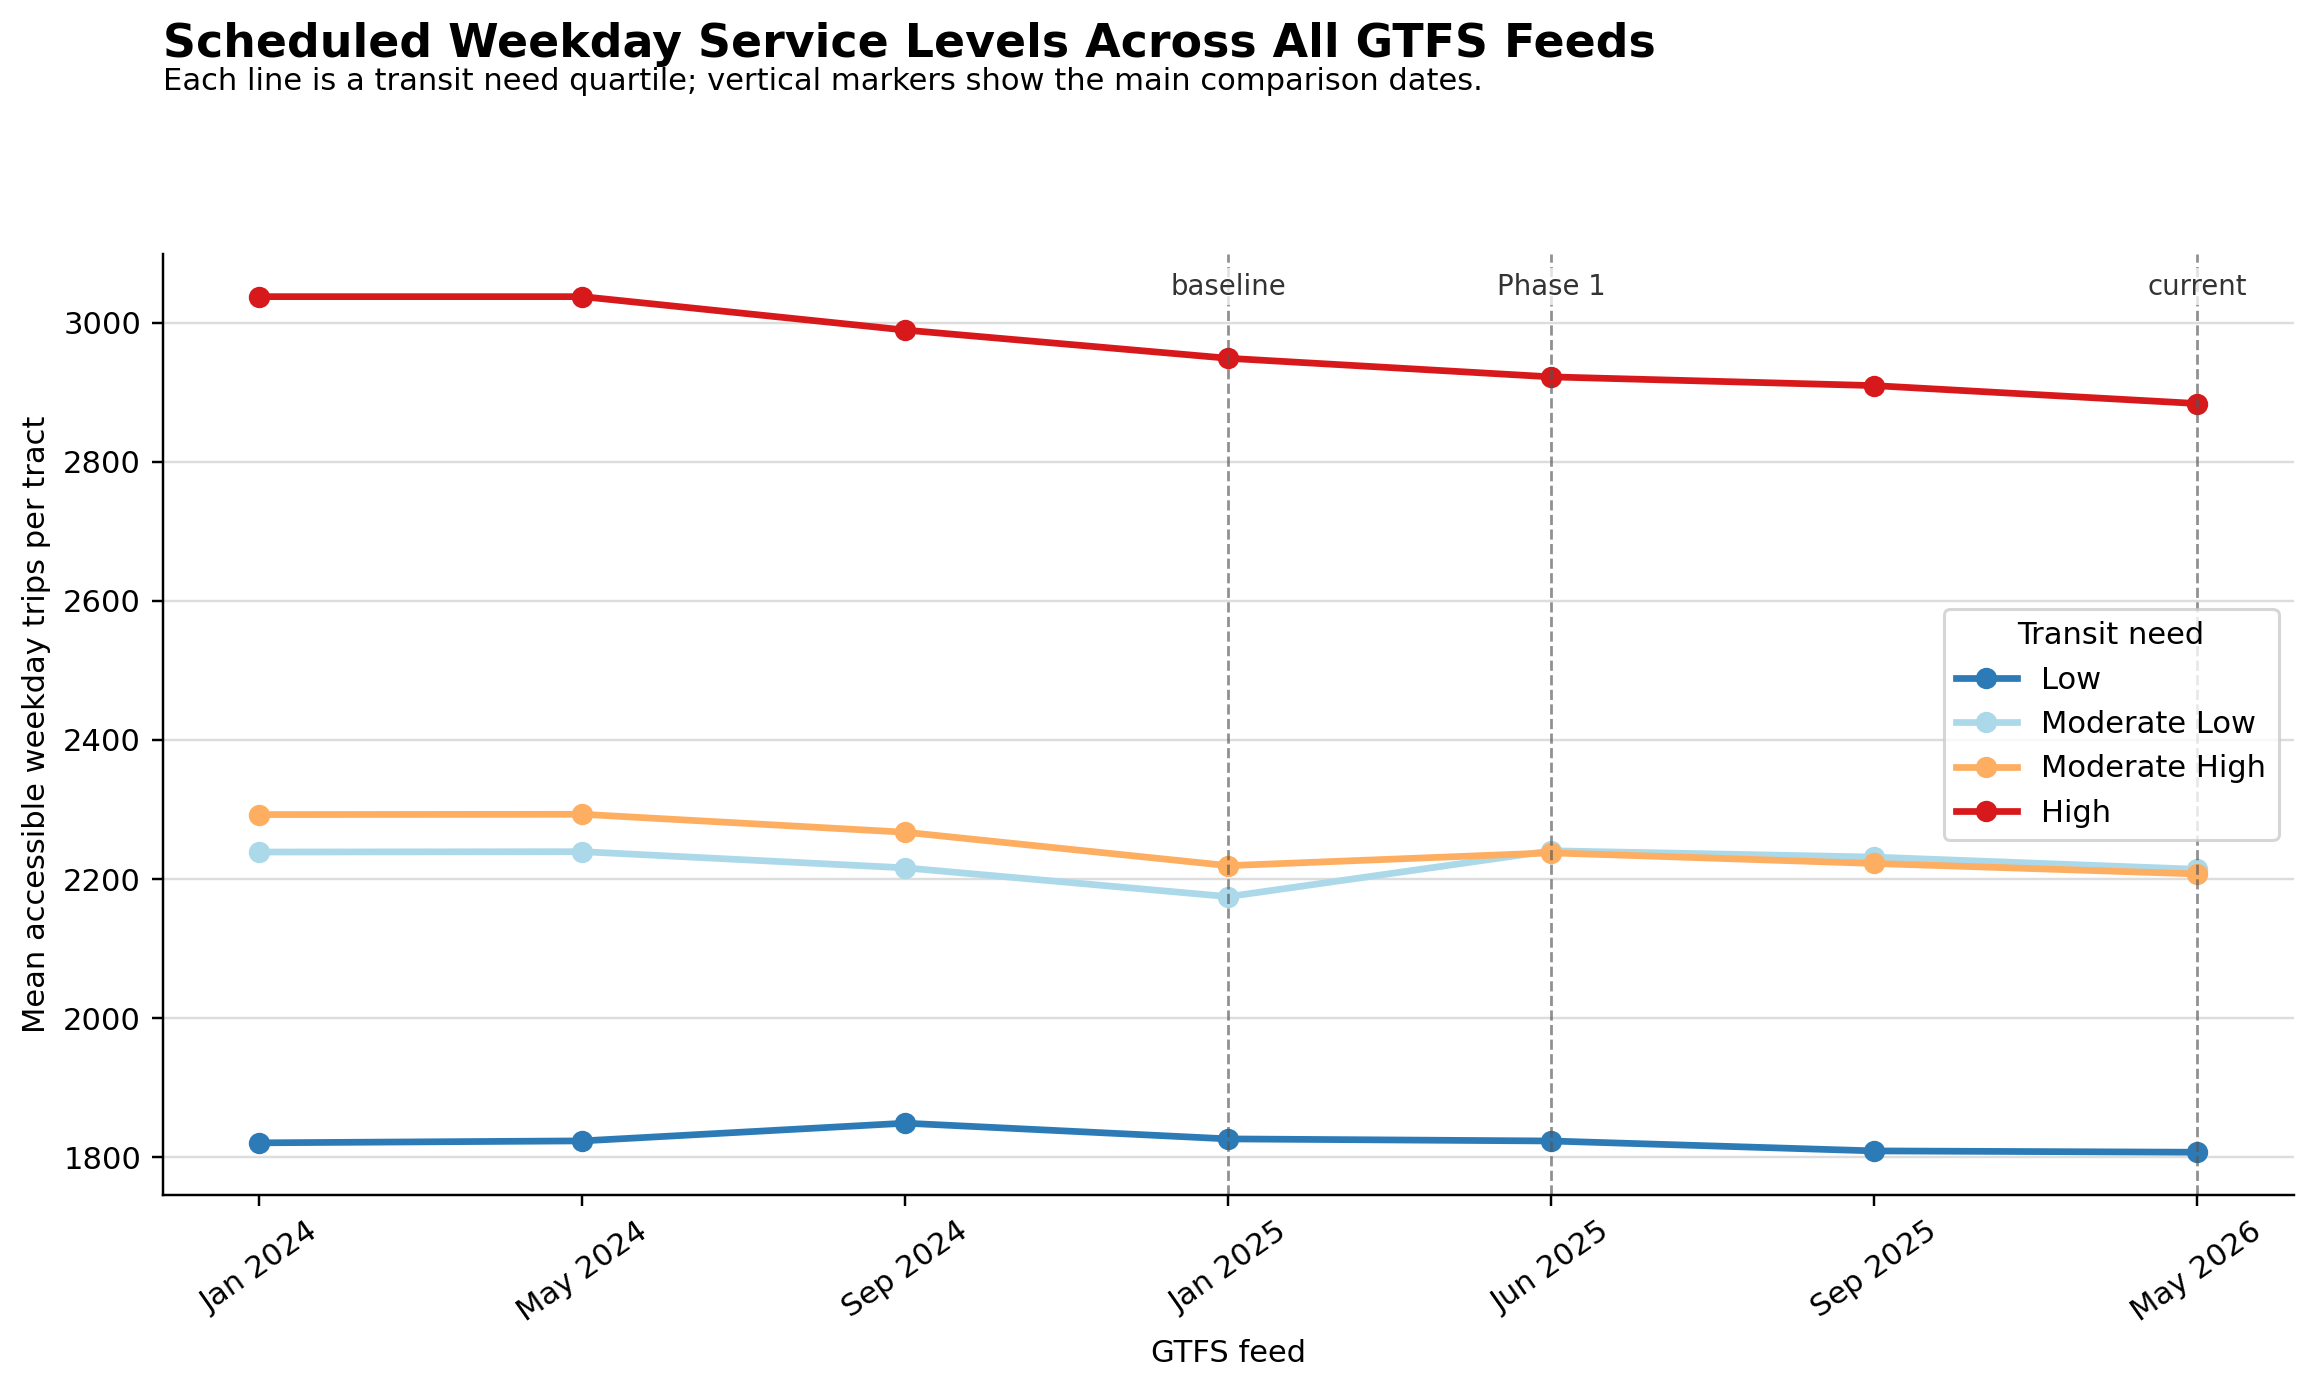

In [9]:
# Display the service trend chart by transit need quartile.
display(Image(filename=str(final_figure_dir / "trend_weekday_service_by_need_quartile.png")))


The map shows the average number of accessible scheduled weekday trips by transit need quartile across the downloaded GTFS feeds. The important pattern is that high-need tracts already had the highest average nearby scheduled service at the January 2025 baseline. This changes the interpretation of equity: the project is not only asking whether high-need places had service, but whether they gained more service after implementation. The figure shows that the high-need line does not rise more than the others after June 29, 2025, which weakens the hypothesis that Phase 1 concentrated new scheduled service in the highest-need tract group.


## 9. Primary Pre/Post Phase 1 Comparison Table


In [10]:
# Read the tract-level pre/post Phase 1 service-change table.
phase1_change = pd.read_csv(final_output_dir / "tract_service_change_phase1_2025jan_to_2025jun_025mi.csv")

# Read the summary of Phase 1 service change by transit need quartile.
phase1_quartile_summary = pd.read_csv(final_output_dir / "phase1_2025jan_to_2025jun_quartile_summary.csv")

# Display the Phase 1 quartile summary.
phase1_quartile_summary


,transit_need_quartile,n_tracts,mean_transit_need_index,mean_baseline_weekday_trips,mean_weekday_trip_change,median_weekday_trip_change,mean_weekend_trip_change,mean_peak_frequency_change,mean_weekday_trips_per_1000_change,mean_accessible_stop_change
0,low,58,-0.562571,1826.310345,-3.000000,-10.5,-38.879310,-0.767241,0.010005,-2.396552
1,moderate_low,58,-0.305439,2174.724138,65.965517,0.0,1.741379,4.262931,8.951780,-1.275862
2,moderate_high,58,0.016882,2219.258621,18.413793,-4.0,8.706897,0.612069,3.415405,-2.155172
3,high,58,0.851128,2948.913793,-26.741379,-20.5,-57.448276,-1.806034,-7.106909,-3.500000


## 10. Primary Pre/Post Statistical Test Table

1. Read the statistical tests for the Phase 1 comparison.
2. Display the tests that evaluate whether need and service gains are associated.
3. Use the p-values to judge whether the observed pattern is statistically strong.


In [11]:
# Read the statistical tests for the Phase 1 equity comparison.
phase1_tests = pd.read_csv(final_output_dir / "phase1_2025jan_to_2025jun_equity_tests.csv")

# Display the Phase 1 statistical test results.
phase1_tests


,test,metric,statistic,p_value,high_need_mean,other_tracts_mean,interpretation_note
0,Welch t-test: high need vs all other tracts,weekday_total_trips_accessible_change,-0.743455,0.459262,-26.741379,27.126437,Positive difference means high-need tracts gai...
1,Pearson correlation,weekday_total_trips_accessible_change,-0.031506,0.633074,NaN,NaN,Positive correlation means higher transit need...
2,Spearman rank correlation,weekday_total_trips_accessible_change,-0.019025,0.773168,NaN,NaN,Positive correlation means higher transit need...


This table tests whether the descriptive pattern in Table 5 is statistically supported. The Welch t-test and correlation results do not show statistically significant evidence that higher transit need is associated with larger scheduled weekday service gains in the Phase 1 comparison. The analysis does not find evidence for the hypothesis, but it also does not prove that the redesign had no equity considerations.


## 11. The Main Pre/Post Result

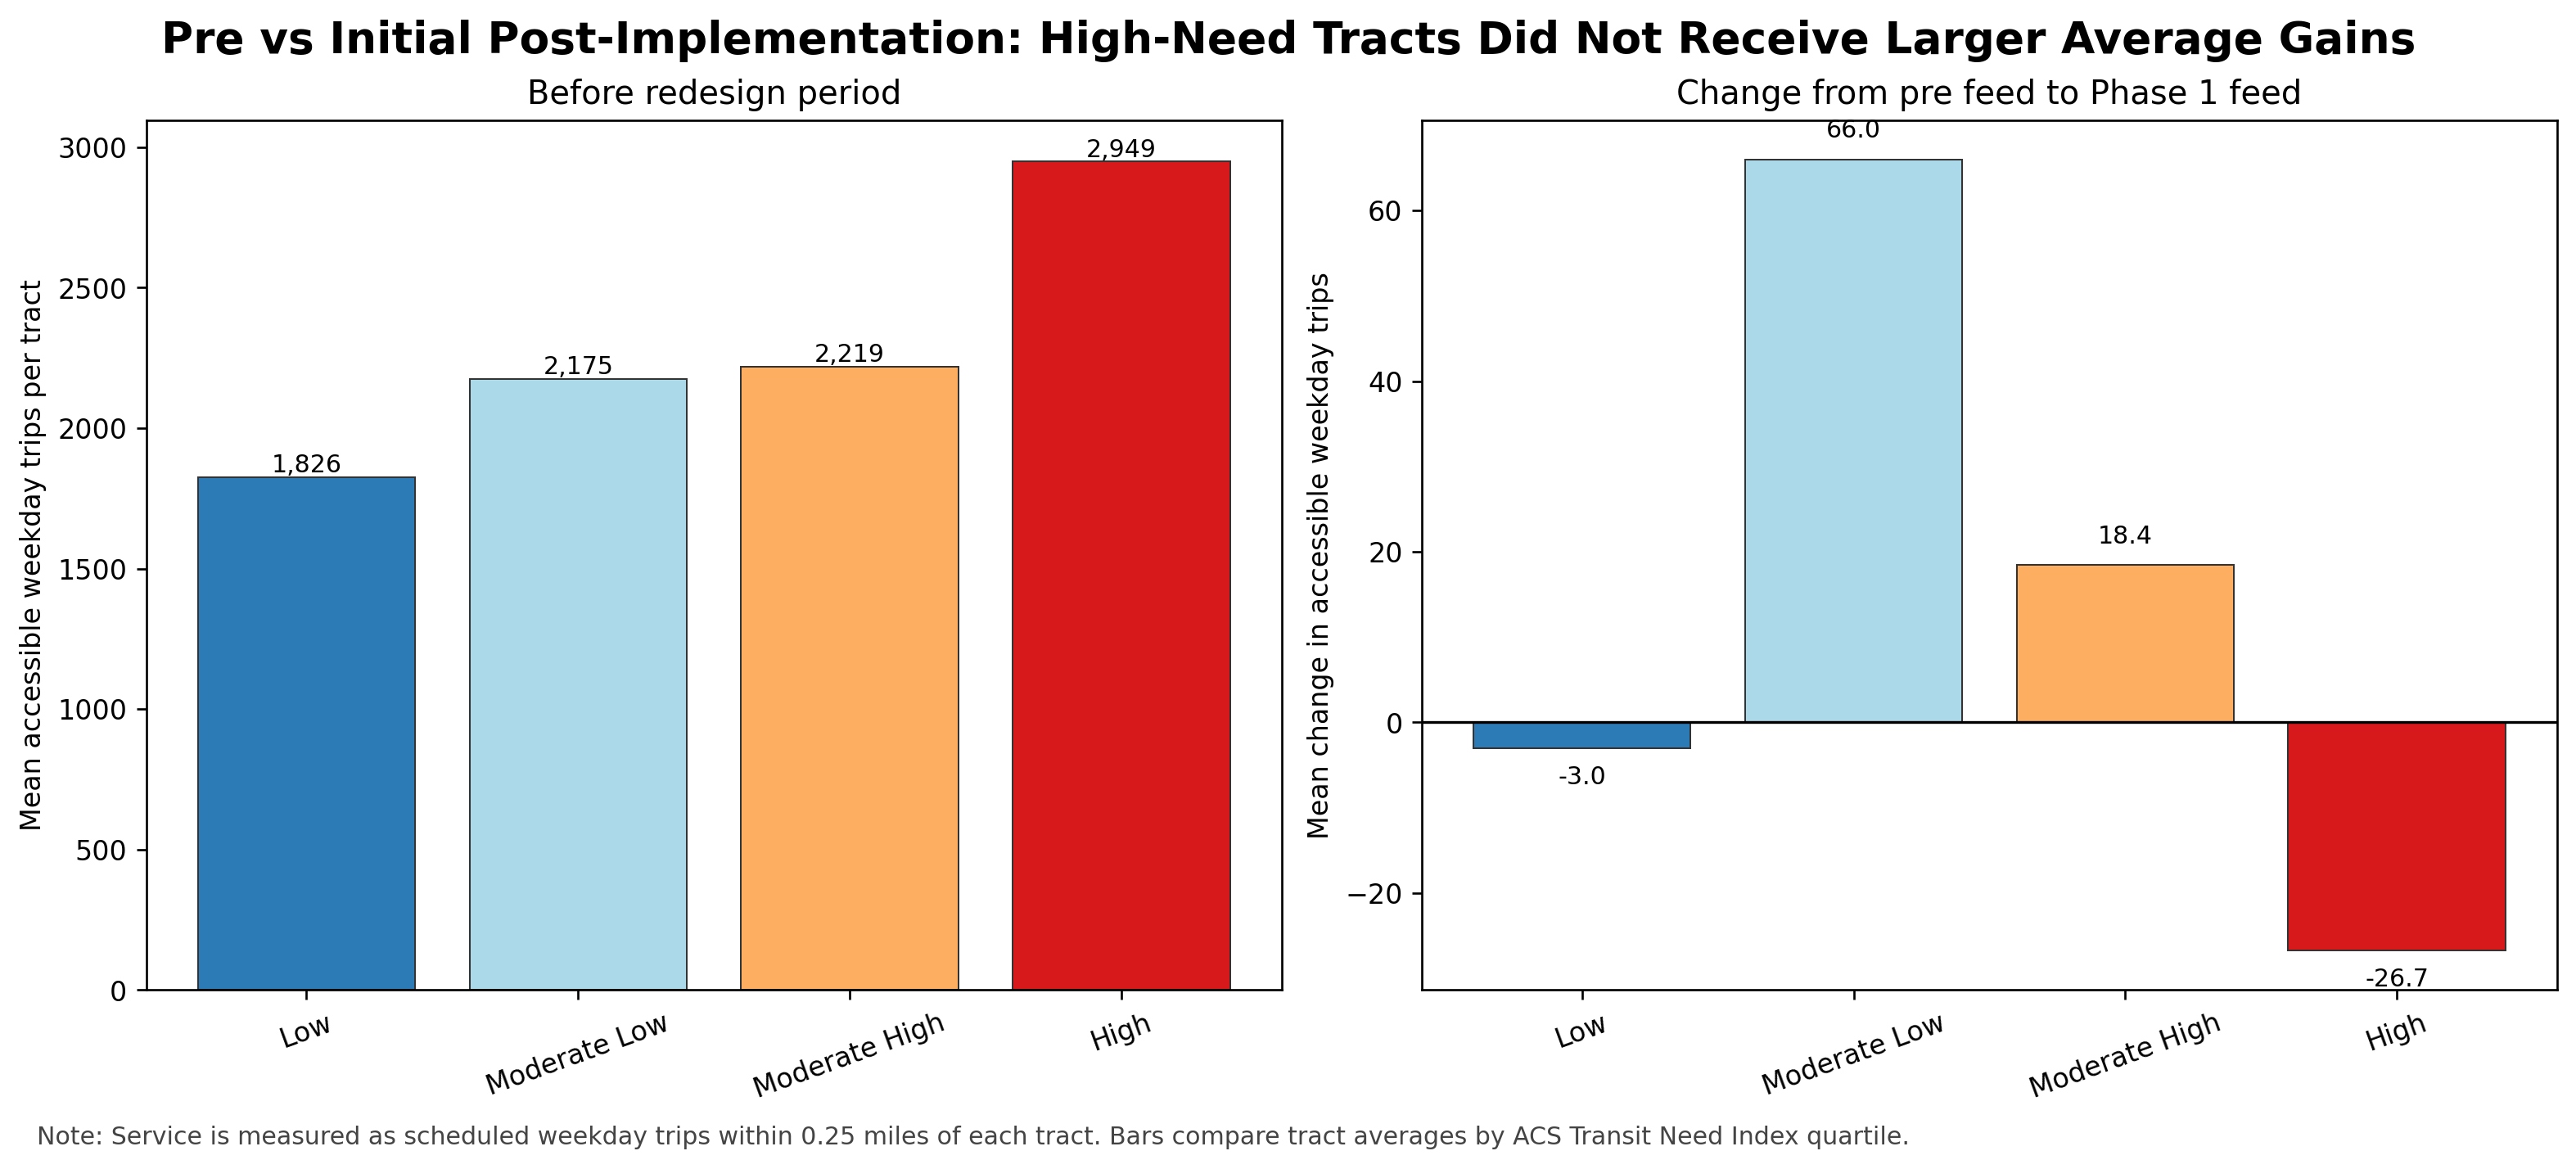

In [12]:
# Display the main pre/post chart for the Phase 1 comparison.
display(Image(filename=str(final_figure_dir / "figure_05_phase1_baseline_and_change_by_need.png")))


THis figure translates the main table into a visual comparison of baseline service and service change. The left panel shows that high-need tracts began with the highest average accessible weekday service, while the right panel shows that they did not receive the largest average gain after implementation. The evidence suggests that Phase 1 did not produce larger average scheduled service gains in the highest-need tract group.


## 12. Mapping The Main Pre/Post Service Change

1. Display the Phase 1 service-change map.
2. Compare gain and loss areas geographically.
3. Use the map to see where the average pattern is happening spatially.


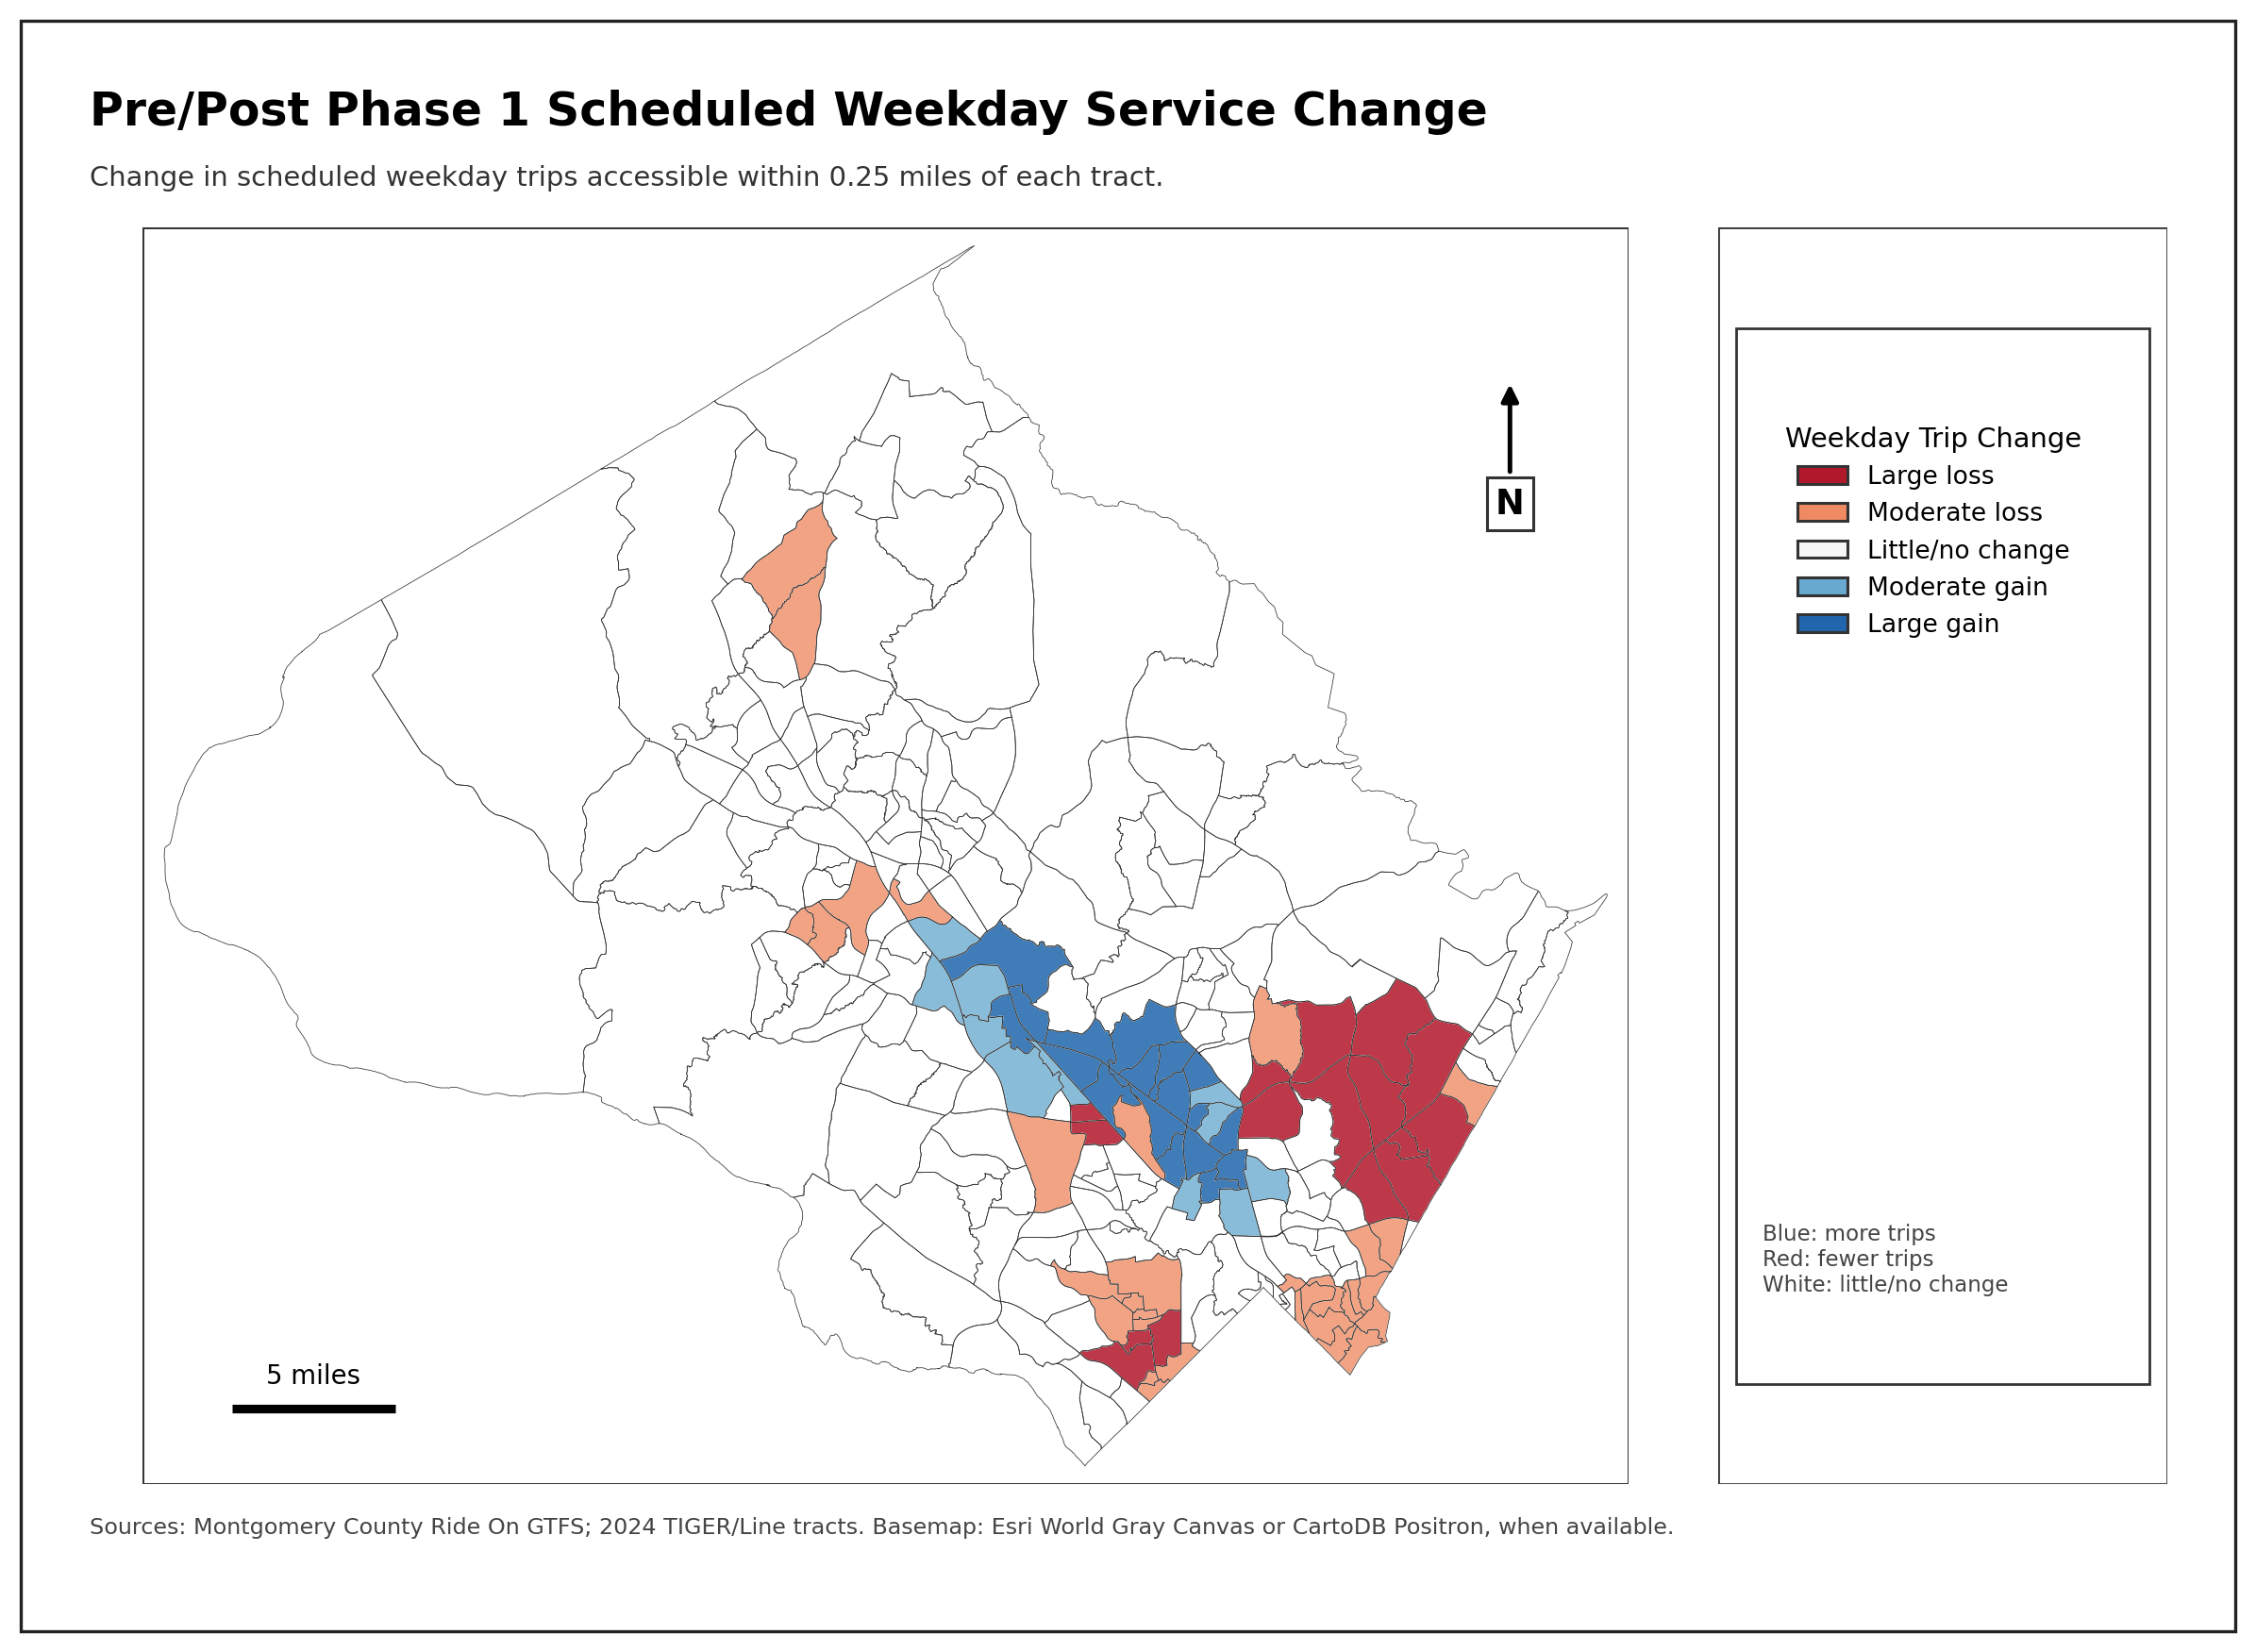

In [13]:
# Display the pre/post Phase 1 scheduled service change map.
display(Image(filename=str(final_figure_dir / "map_02_phase1_weekday_trip_change_categories.png")))


The map shows the geography of scheduled weekday service change from the pre-implementation feed to the Phase 1 feed. Blue tracts gained nearby scheduled trips, red and orange tracts lost nearby scheduled trips, and white tracts changed little. The map shows that the redesign produced a spatially uneven redistribution of scheduled service rather than a uniform countywide improvement.

## 13. Mapping High-Need Tracts With Service Losses

1. Display the high-need watchlist map.
2. Highlight tracts that are both high need and negative service change.

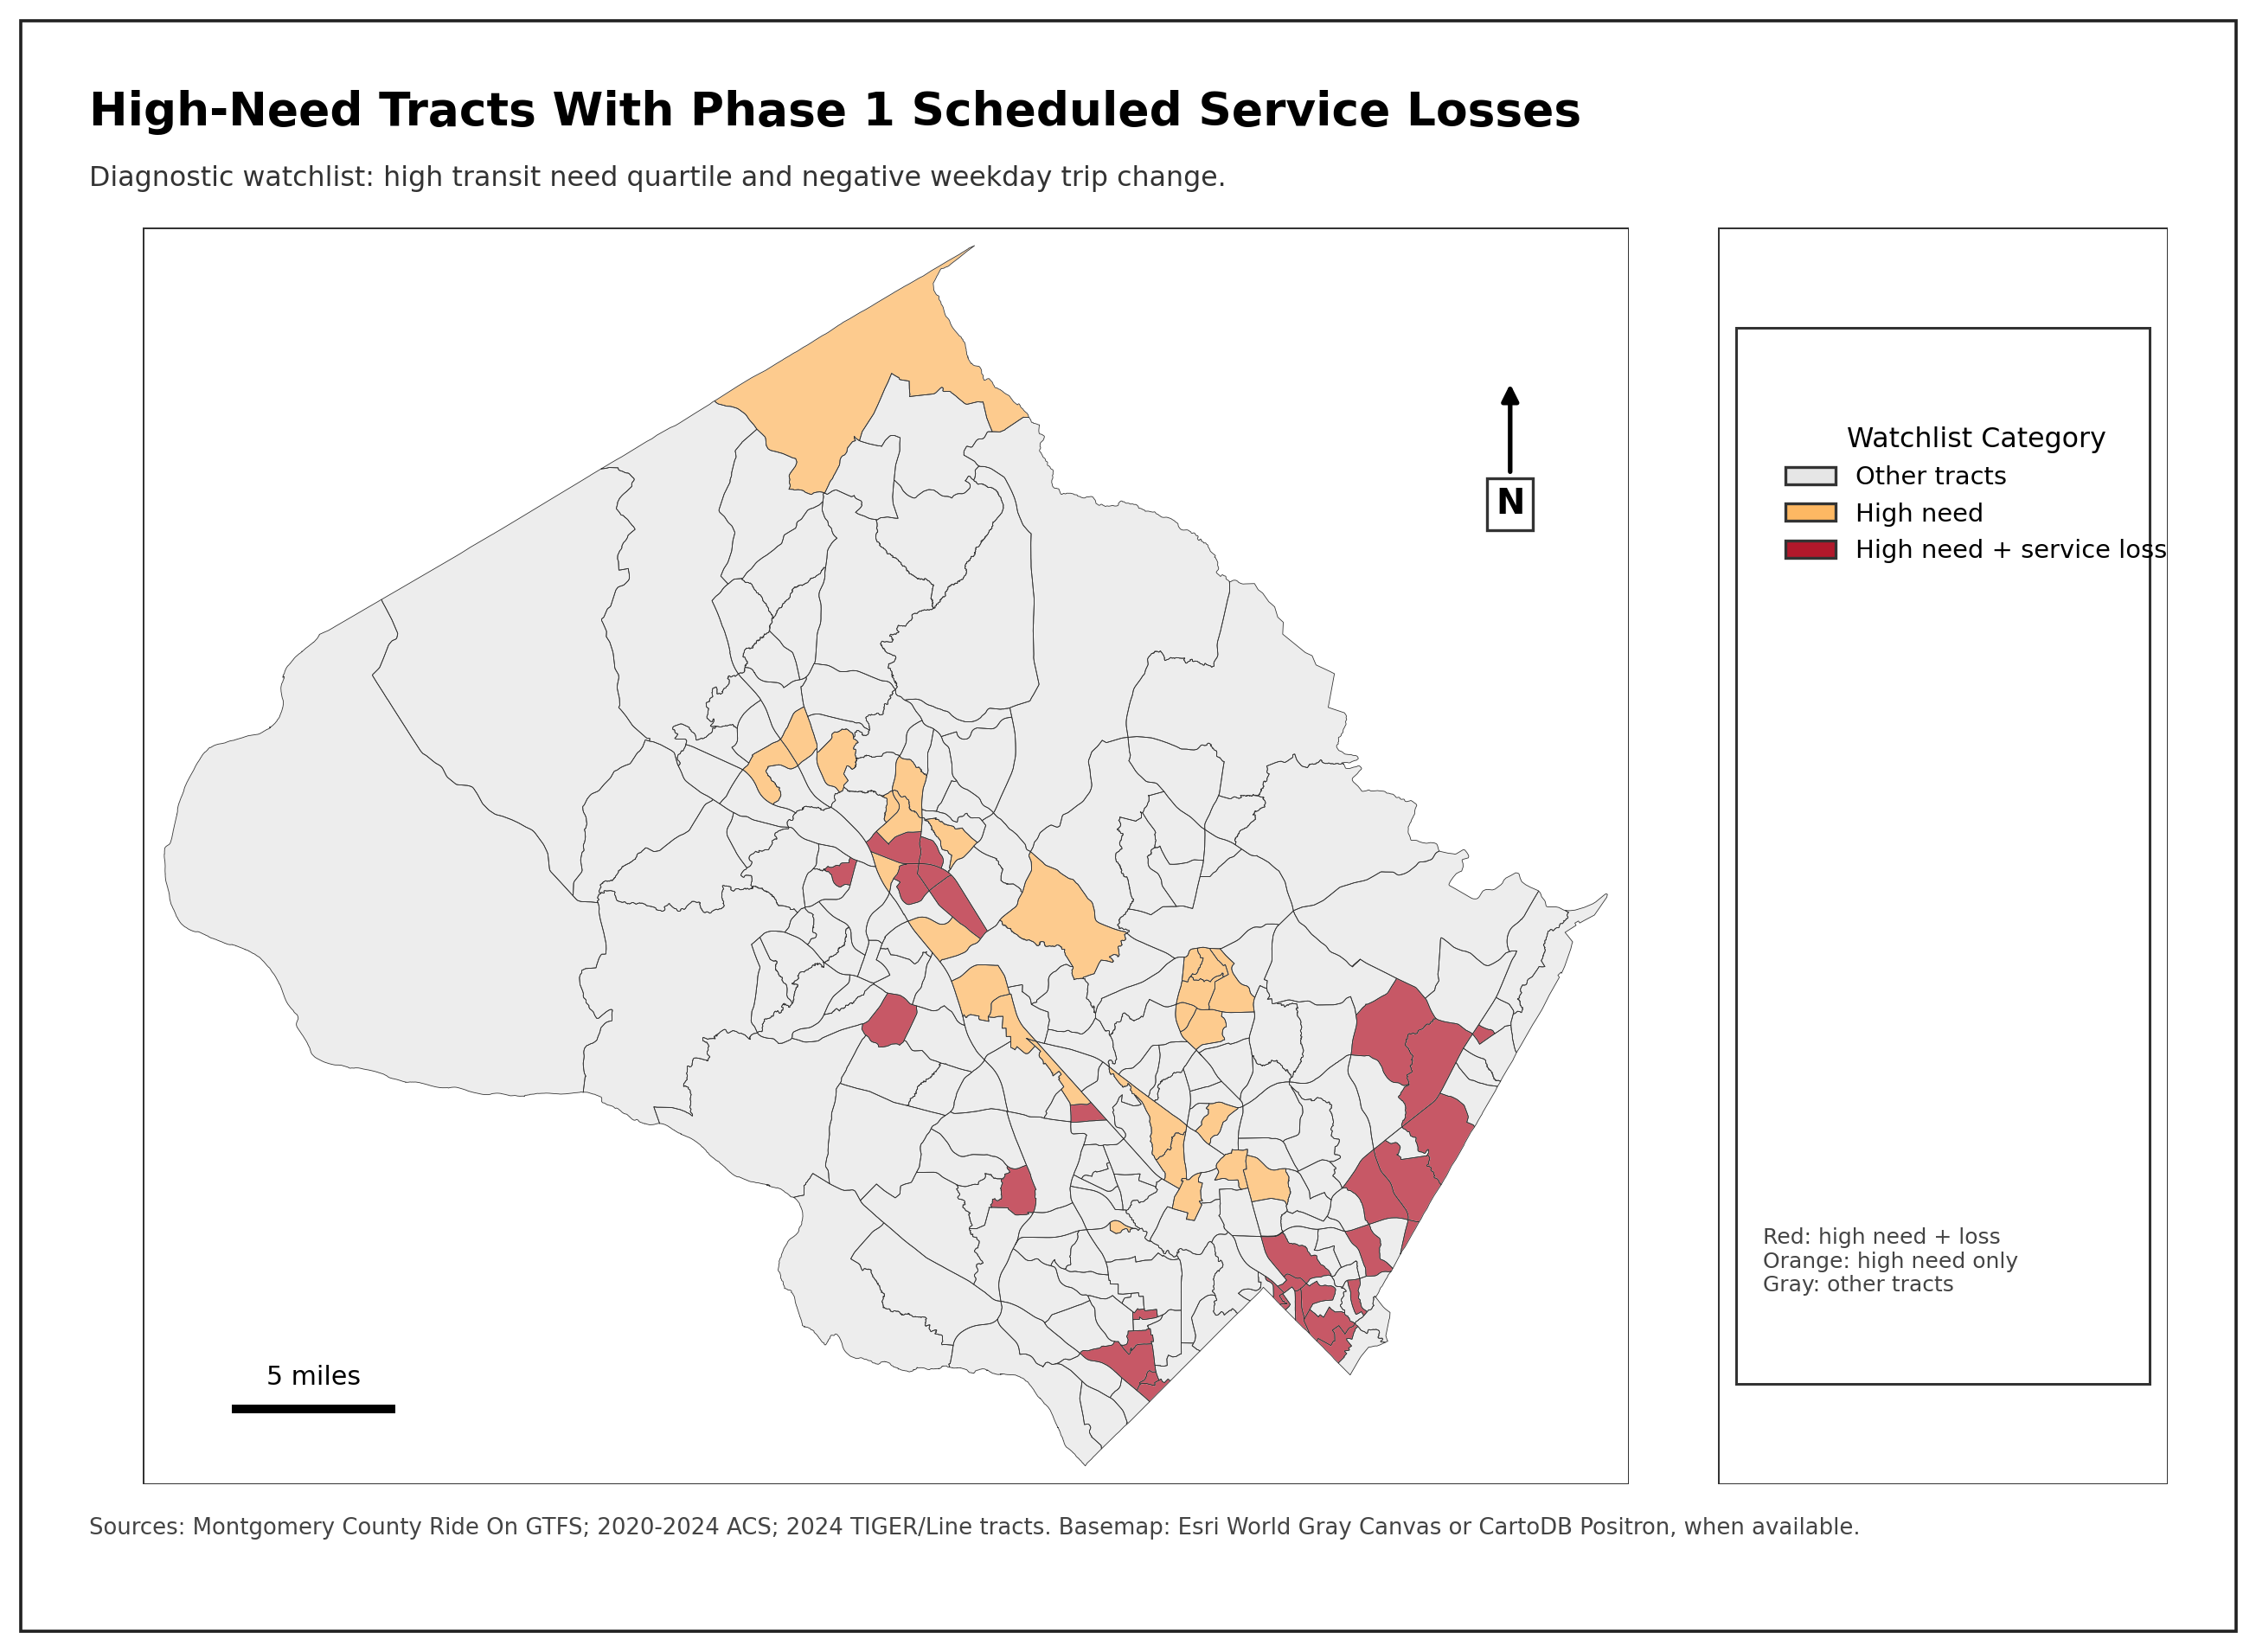

In [14]:
# Display the high-need plus service-loss watchlist map.
display(Image(filename=str(final_figure_dir / "map_03_high_need_service_loss_watchlist.png")))


The map identifies tracts where two conditions overlap: high ACS transit need and negative scheduled weekday service change after Phase 1. These tracts are the strongest mismatch cases in the project because they combine high measured need with limited or negative improvement under the scheduled-service method. 

## 14. Published 2026 Schedule Sensitivity Check Table

1. Read the January 2025 to May 2026 published schedule comparison summary.
2. Read the statistical tests for this later published schedule comparison.
3. Display the quartile summary.

In [15]:
# Read the current-feed comparison summary.
current_quartile_summary = pd.read_csv(final_output_dir / "current_2025jan_to_2026may_quartile_summary.csv")

# Read the current-feed statistical tests.
current_tests = pd.read_csv(final_output_dir / "current_2025jan_to_2026may_equity_tests.csv")

# Display the current-feed quartile summary.
current_quartile_summary


,transit_need_quartile,n_tracts,mean_transit_need_index,mean_baseline_weekday_trips,mean_weekday_trip_change,median_weekday_trip_change,mean_weekend_trip_change,mean_peak_frequency_change,mean_weekday_trips_per_1000_change,mean_accessible_stop_change
0,low,58,-0.562571,1826.310345,-19.189655,-18.0,-41.793103,-1.400862,-3.904001,-2.448276
1,moderate_low,58,-0.305439,2174.724138,39.310345,0.0,-8.431034,1.646552,2.615735,-1.637931
2,moderate_high,58,0.016882,2219.258621,-11.879310,-16.5,-4.017241,-2.508621,-3.447805,-2.465517
3,high,58,0.851128,2948.913793,-65.068966,-41.0,-73.948276,-5.564655,-16.991238,-3.706897


The high-need quartile still does not show the largest average scheduled service gain. This supports the robustness of the Phase 1 finding, but the table includes future dates through September 5, 2026.

## 15. Published 2026 Schedule Sensitivity Test Table


In [16]:
# Display the current-feed statistical test results.
current_tests


,test,metric,statistic,p_value,high_need_mean,other_tracts_mean,interpretation_note
0,Welch t-test: high need vs all other tracts,weekday_total_trips_accessible_change,-0.950589,0.344579,-65.068966,2.747126,Positive difference means high-need tracts gai...
1,Pearson correlation,weekday_total_trips_accessible_change,-0.041696,0.527431,NaN,NaN,Positive correlation means higher transit need...
2,Spearman rank correlation,weekday_total_trips_accessible_change,-0.088911,0.177139,NaN,NaN,Positive correlation means higher transit need...


The table repeats the equity tests using the May 2026 published schedule comparison. The results again do not show statistically significant evidence that higher-need tracts received larger scheduled weekday service gains. This makes the overall finding more stable across the available published schedules.

## 16. Published 2026 Schedule Sensitivity Chart

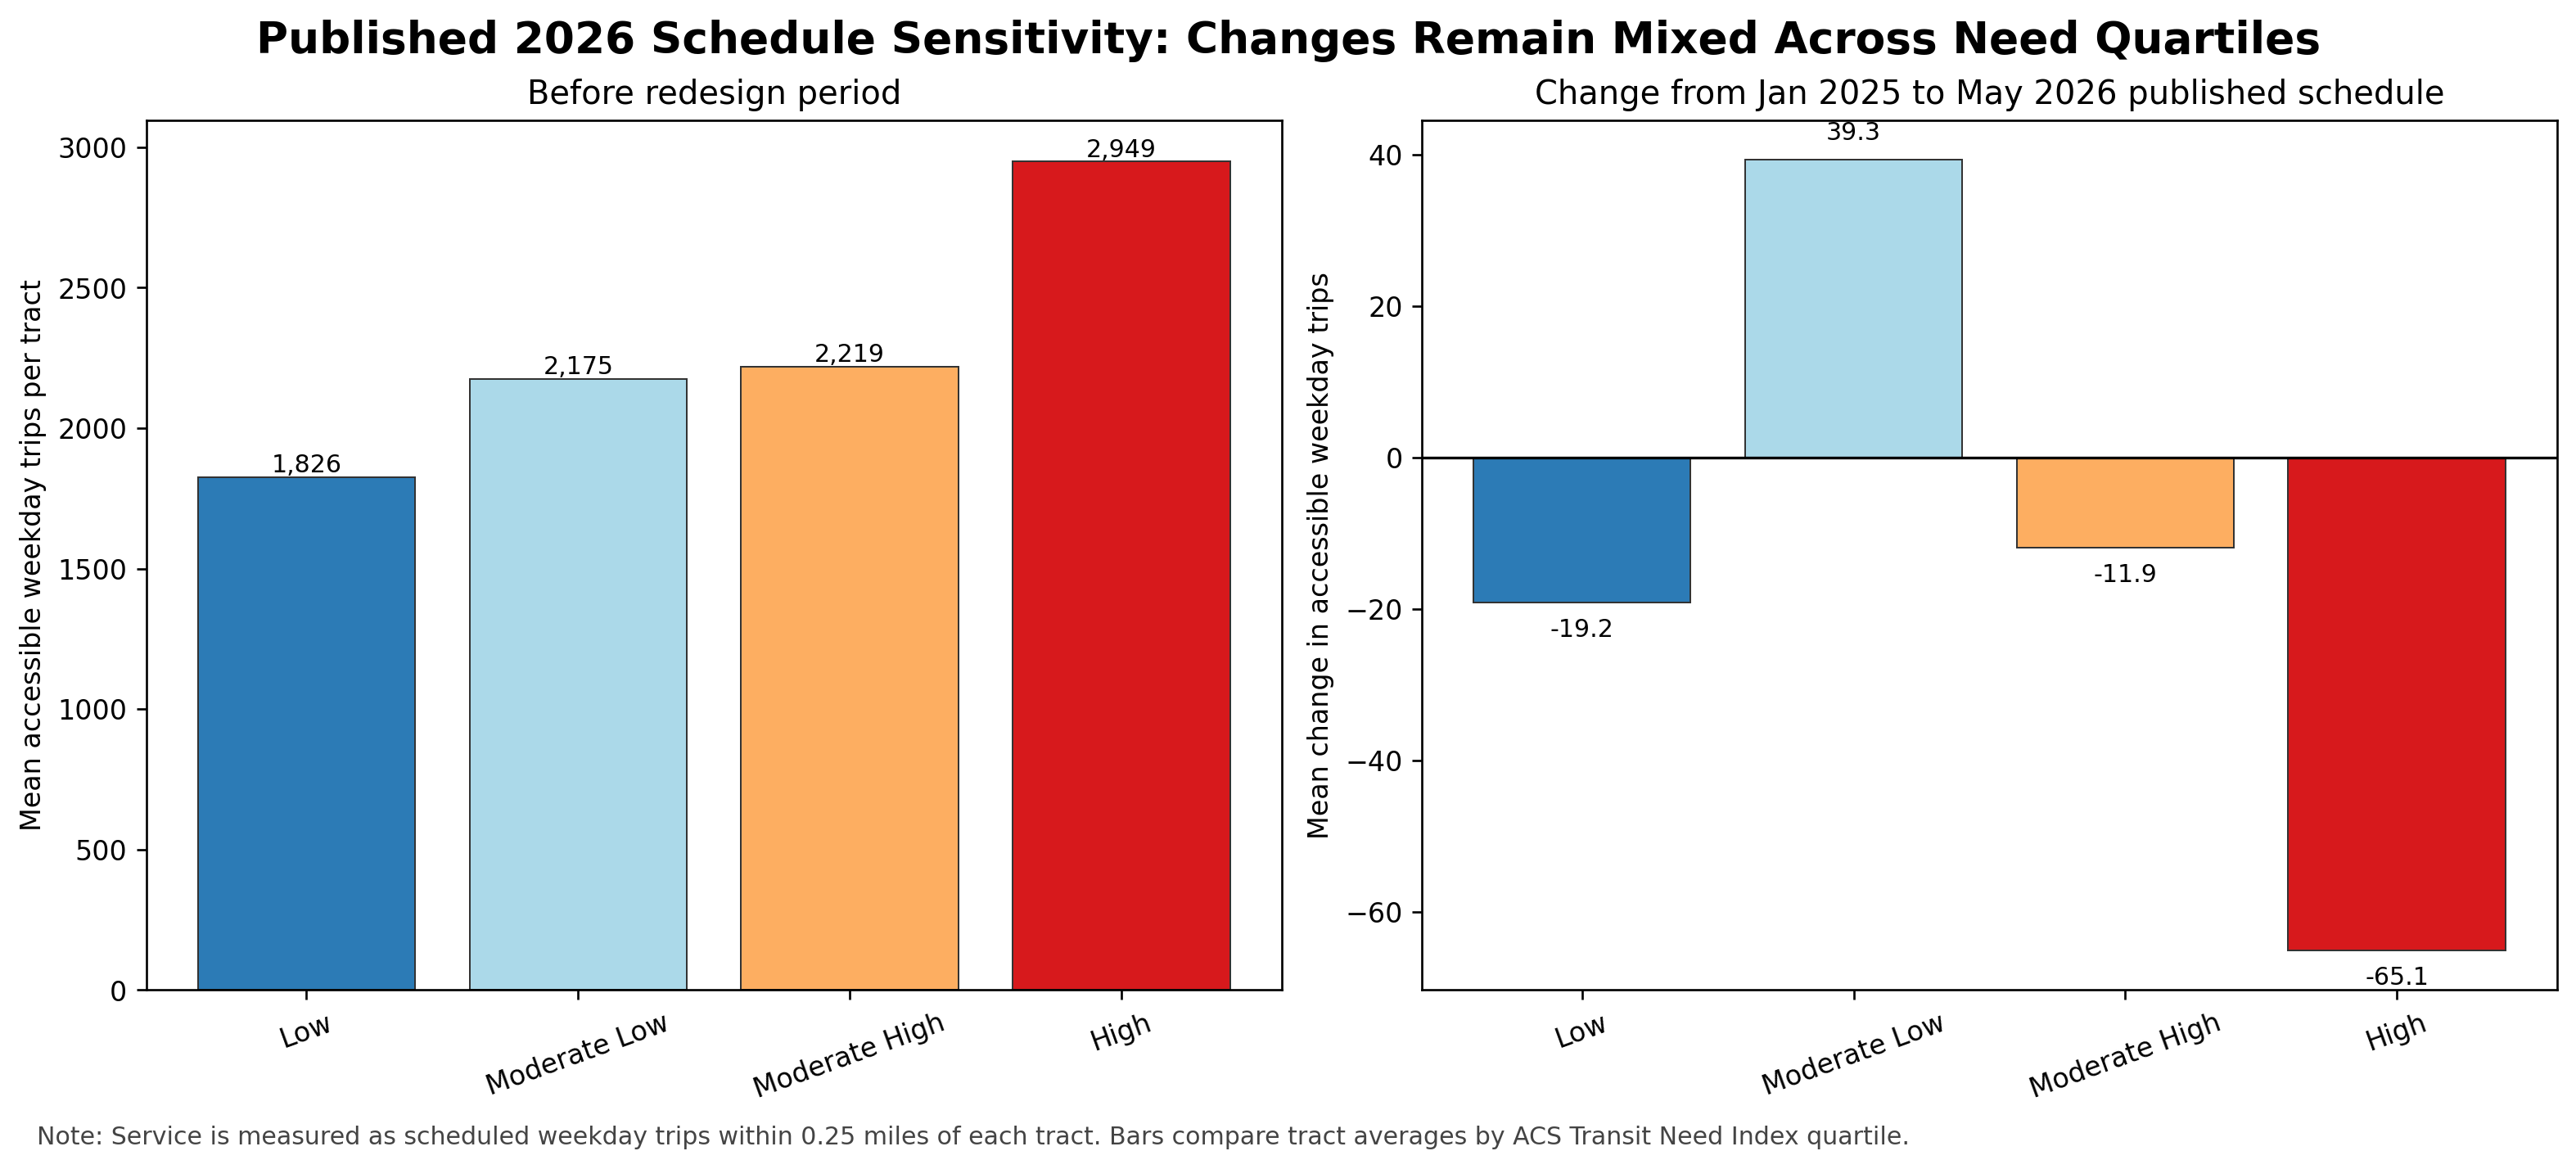

In [17]:
# Display the current published feed comparison chart.
display(Image(filename=str(final_figure_dir / "figure_06_current_baseline_and_change_by_need.png")))


The figure visualizes the published 2026 schedule sensitivity check. The chart shows that the later published schedule still produces a mixed pattern across need quartiles, with no clear concentration of gains in the highest-need group. 

## 17. Published 2026 Schedule Sensitivity Map

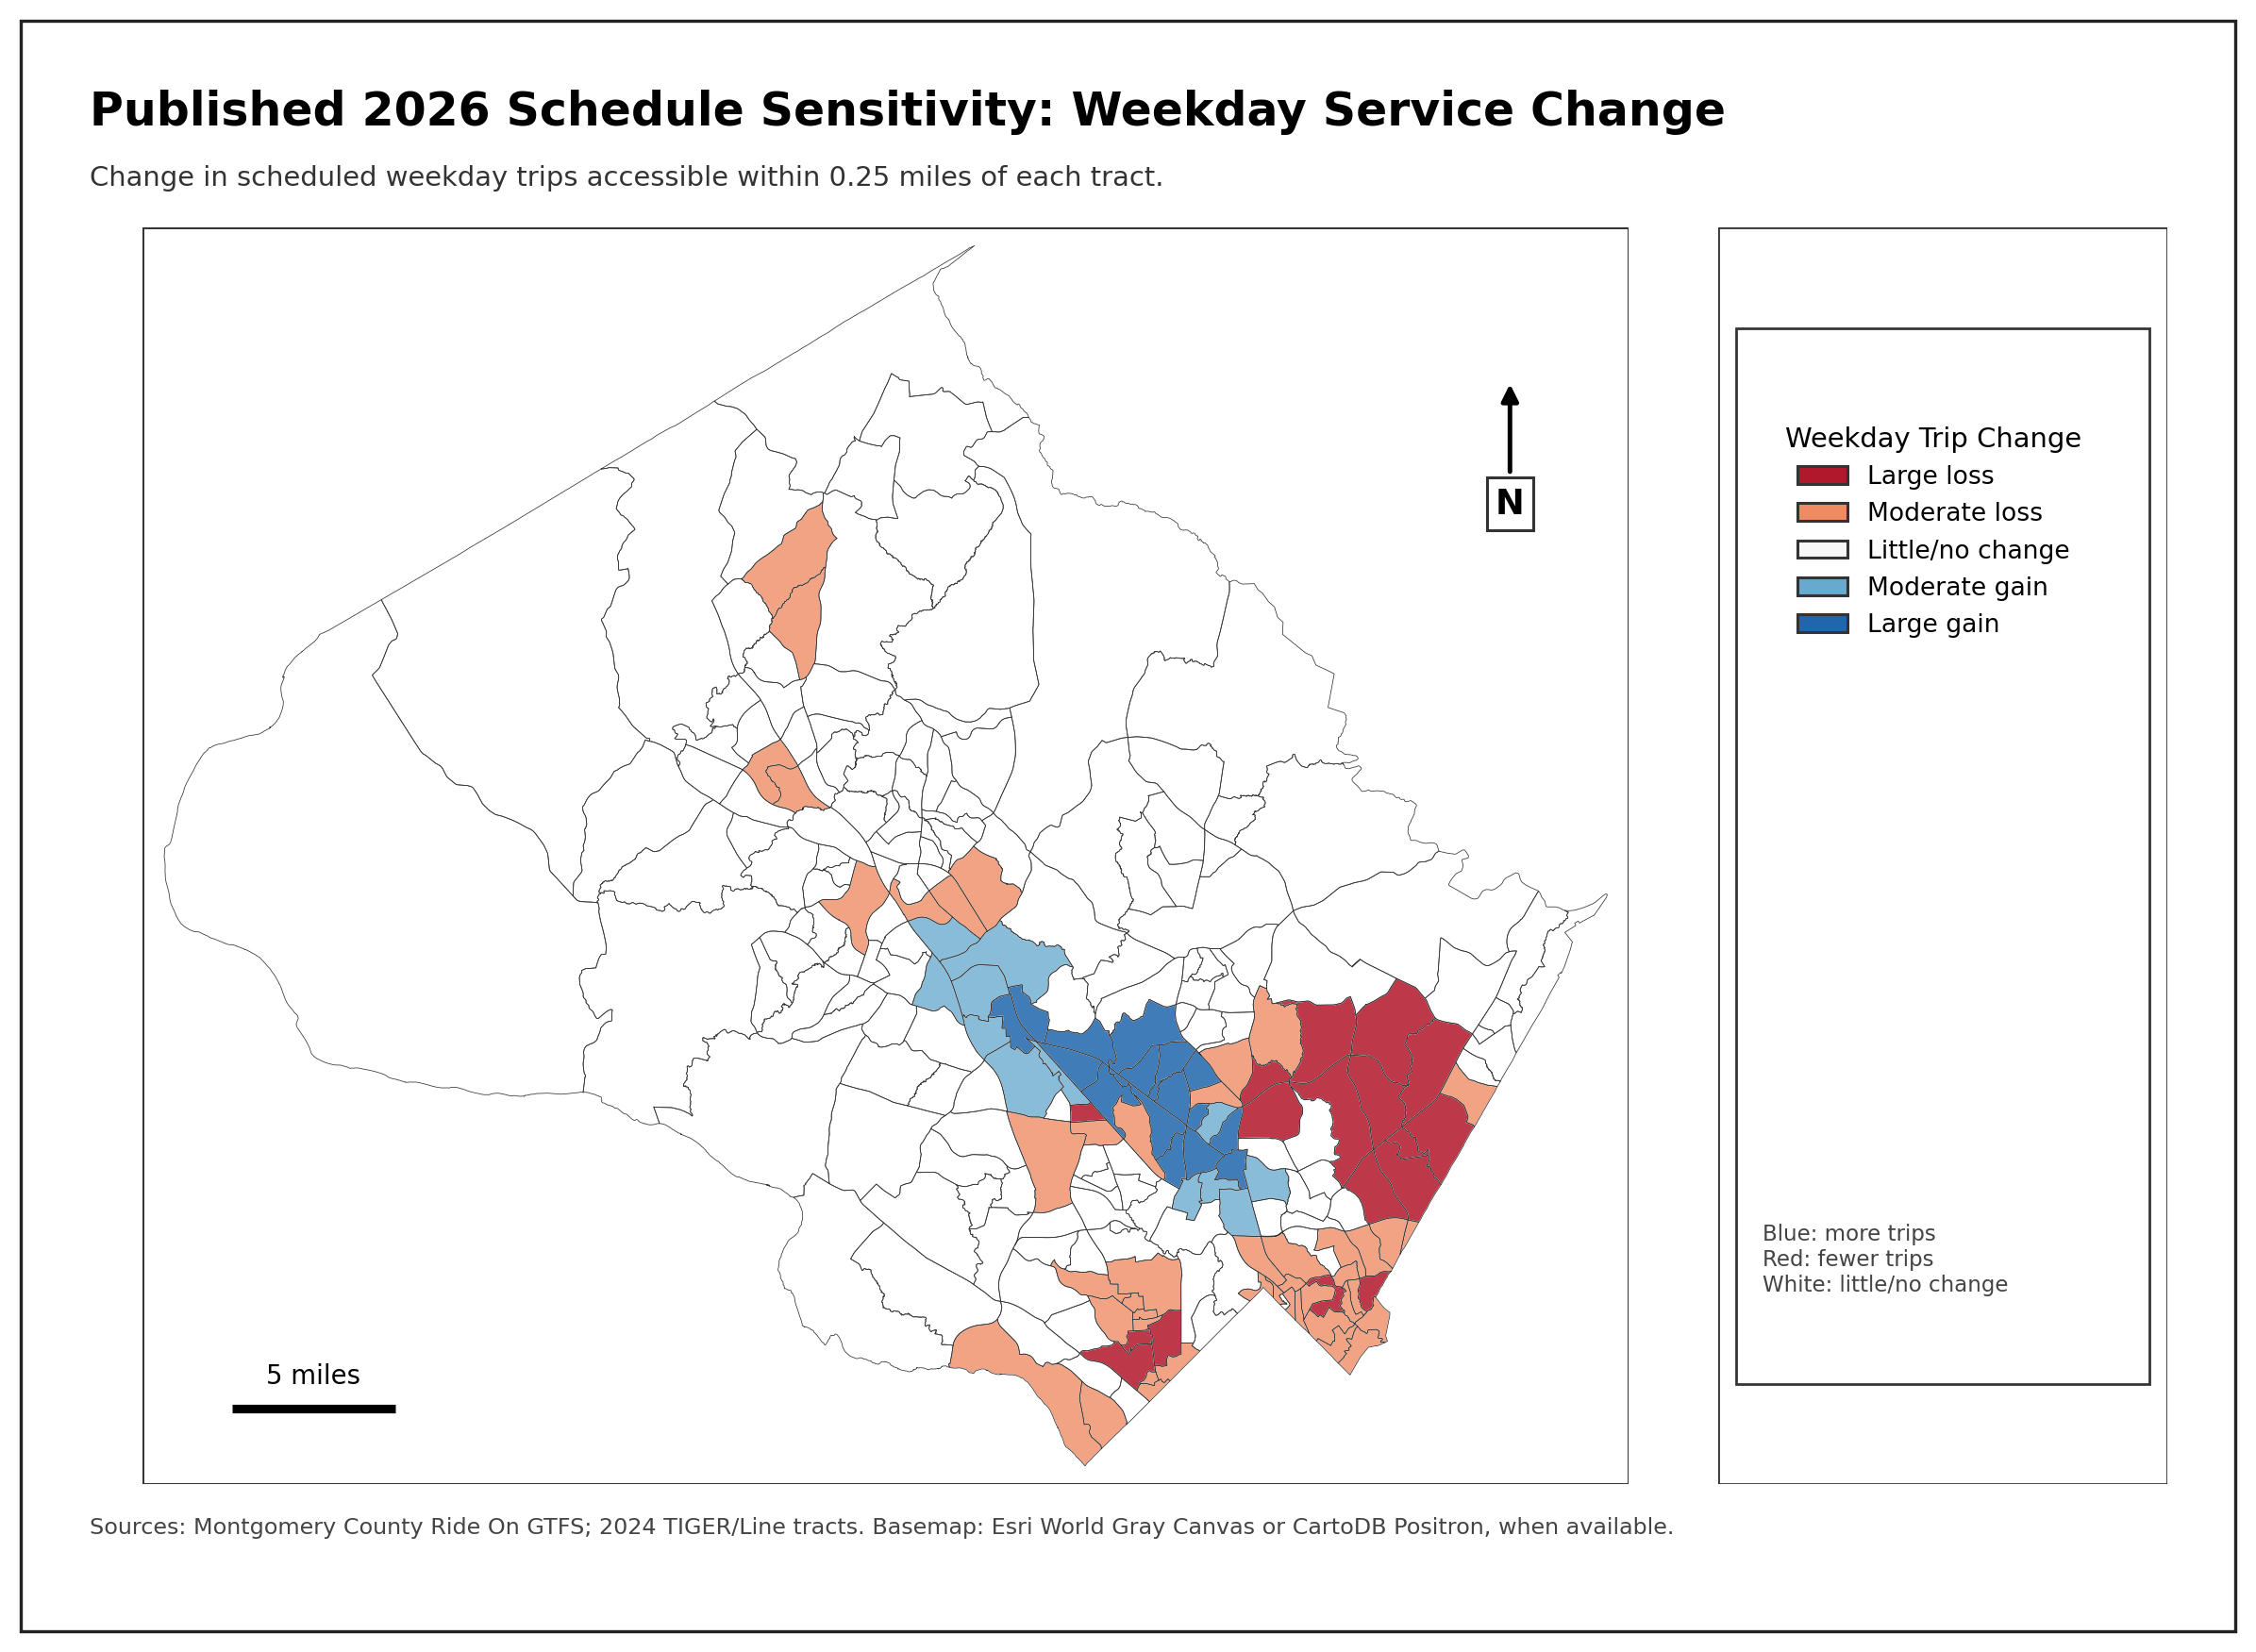

In [18]:
# Display the current published feed service-change map.
display(Image(filename=str(final_figure_dir / "map_04_current_weekday_trip_change_categories.png")))


 The map shows scheduled service change from the January 2025 baseline to the May 2026 published schedule. The spatial pattern remains mixed, with gains, losses, and little-change tracts occurring across the county.


## 18. High-Need Watchlist Table

In [19]:
# Read the high-need tract watchlist for the Phase 1 comparison.
watchlist = pd.read_csv(final_output_dir / "phase1_2025jan_to_2025jun_high_need_limited_improvement_watchlist.csv")

# Display the first ten watchlist tracts.
watchlist.head(10)


,GEOID,tract_name,transit_need_index,transit_need_percentile,pct_households_no_vehicle,pct_people_below_poverty,pct_disabled,weekday_total_trips_accessible_2025_january,weekday_total_trips_accessible_change,weekend_total_trips_accessible_change,accessible_stop_count_change
0,24031701509,Census Tract 7015.09; Montgomery County; Maryland,0.644966,0.866379,17.0,21.2,10.0,2438.0,-1080.0,-690.0,-18.0
1,24031701414,Census Tract 7014.14; Montgomery County; Maryland,0.336239,0.801724,11.3,7.8,12.9,1715.0,-915.0,-575.0,-24.0
2,24031701415,Census Tract 7014.15; Montgomery County; Maryland,0.242052,0.762931,3.5,9.6,12.7,1392.0,-900.0,-575.0,-25.0
3,24031705502,Census Tract 7055.02; Montgomery County; Maryland,0.393739,0.823276,5.5,9.3,13.5,1739.0,-789.0,-993.0,-21.0
4,24031701425,Census Tract 7014.25; Montgomery County; Maryland,1.657578,0.978448,20.3,5.4,24.0,1854.0,-648.0,-414.0,-16.0
5,24031701218,Census Tract 7012.18; Montgomery County; Maryland,1.176527,0.956897,19.8,5.8,19.6,4237.0,-627.0,-417.0,-14.0
6,24031701505,Census Tract 7015.05; Montgomery County; Maryland,0.641617,0.862069,16.0,13.6,13.4,2666.0,-576.0,-368.0,-4.0
7,24031704803,Census Tract 7048.03; Montgomery County; Maryland,0.258759,0.767241,14.2,6.3,11.8,851.0,-546.0,-406.0,-14.0
8,24031705602,Census Tract 7056.02; Montgomery County; Maryland,1.494023,0.974138,19.9,9.5,15.6,1148.0,-448.0,-681.0,-11.0
9,24031705501,Census Tract 7055.01; Montgomery County; Maryland,0.675107,0.887931,30.1,6.0,11.5,1221.0,-292.0,-647.0,-7.0


The table lists high-need tracts with the most limited or negative Phase 1 service change. This gives the project concrete tract-level cases for discussion rather than relying only on countywide averages.

## 19. Conclusion

This analysis helps answer the final project question. It identifies higher-transit-need areas with ACS data, joins those areas to GTFS-based scheduled service measures, and compares pre/post Ride On Reimagined service change.

The conclusion is:

> Using scheduled GTFS service and 0.25-mile tract catchments, Ride On Reimagined Phase 1/Year 1 service gains were not clearly concentrated in the highest-transit-need tracts.